# Bar Sales Intelligence Dashboard

1. Project Overview
2. Import Libraries
3. Load Dataset
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis
7. Visualizations
8. Key Insights
9. Business Recommendations
10. Conclusion

## Project Overview

This project analyzes simulated bar sales transaction data to identify top-performing drinks, peak revenue periods, and operational opportunities. The goal is to use Python-based data analysis to generate business insights that could improve staffing, inventory planning, and sales strategy.

### Objectives
- Identify the highest revenue-generating drinks
- Analyze sales patterns by hour and shift
- Evaluate category-level performance
- Generate business recommendations based on sales trends

## Import Libraries

In [30]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import os

## Load Dataset

In [31]:
from google.colab import files
uploaded = files.upload()

Saving bar_sales.csv to bar_sales (1).csv


In [32]:
df = pd.read_csv("bar_sales.csv")


## Data Cleaning

In [33]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5585 entries, 0 to 5584
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          5585 non-null   object 
 1   time          5585 non-null   object 
 2   item_name     5585 non-null   object 
 3   category      5585 non-null   object 
 4   quantity      5585 non-null   int64  
 5   price         5585 non-null   float64
 6   payment_type  5585 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 305.6+ KB


,date,time,item_name,category,quantity,price,payment_type
0,2025-01-01,19:28:32,Stout Beer,Beer,3,8.91,Card
1,2025-01-01,17:56:16,Stout Beer,Beer,3,9.28,Card
2,2025-01-01,16:33:11,Vodka Soda,Cocktail,1,10.85,Card
3,2025-01-01,12:04:08,Vodka Shot,Shot,1,5.40,Card
4,2025-01-01,22:24:20,Mojito,Cocktail,1,10.42,Card


In [34]:
df.isnull().sum()

,0
date,0
time,0
item_name,0
category,0
quantity,0
price,0
payment_type,0


In [35]:
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

In [36]:
df[["date", "time", "datetime"]].head()

,date,time,datetime
0,2025-01-01,19:28:32,2025-01-01 19:28:32
1,2025-01-01,17:56:16,2025-01-01 17:56:16
2,2025-01-01,16:33:11,2025-01-01 16:33:11
3,2025-01-01,12:04:08,2025-01-01 12:04:08
4,2025-01-01,22:24:20,2025-01-01 22:24:20


## Feature Engineering

In [37]:
df = df.drop(columns=["date", "time"])

In [38]:
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [39]:
df = df.dropna()

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df = df.drop_duplicates()

In [42]:
df["revenue"] = df["quantity"] * df["price"]

In [43]:
df.head()

,item_name,category,quantity,price,payment_type,datetime,revenue
0,Stout Beer,Beer,3,8.91,Card,2025-01-01 19:28:32,26.73
1,Stout Beer,Beer,3,9.28,Card,2025-01-01 17:56:16,27.84
2,Vodka Soda,Cocktail,1,10.85,Card,2025-01-01 16:33:11,10.85
3,Vodka Shot,Shot,1,5.40,Card,2025-01-01 12:04:08,5.40
4,Mojito,Cocktail,1,10.42,Card,2025-01-01 22:24:20,10.42


In [44]:
df["hour"] = df["datetime"].dt.hour
df["day_name"] = df["datetime"].dt.day_name()
df["month"] = df["datetime"].dt.month_name()

In [45]:
def get_shift(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Late Night"

df["shift"] = df["hour"].apply(get_shift)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5585 entries, 0 to 5584
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   item_name     5585 non-null   object        
 1   category      5585 non-null   object        
 2   quantity      5585 non-null   int64         
 3   price         5585 non-null   float64       
 4   payment_type  5585 non-null   object        
 5   datetime      5585 non-null   datetime64[ns]
 6   revenue       5585 non-null   float64       
 7   hour          5585 non-null   int32         
 8   day_name      5585 non-null   object        
 9   month         5585 non-null   object        
 10  shift         5585 non-null   object        
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(6)
memory usage: 458.3+ KB


In [47]:
df.head()

,item_name,category,quantity,price,payment_type,datetime,revenue,hour,day_name,month,shift
0,Stout Beer,Beer,3,8.91,Card,2025-01-01 19:28:32,26.73,19,Wednesday,January,Evening
1,Stout Beer,Beer,3,9.28,Card,2025-01-01 17:56:16,27.84,17,Wednesday,January,Evening
2,Vodka Soda,Cocktail,1,10.85,Card,2025-01-01 16:33:11,10.85,16,Wednesday,January,Afternoon
3,Vodka Shot,Shot,1,5.40,Card,2025-01-01 12:04:08,5.40,12,Wednesday,January,Afternoon
4,Mojito,Cocktail,1,10.42,Card,2025-01-01 22:24:20,10.42,22,Wednesday,January,Late Night


## Exploratory Data Analysis (EDA)

Total Revenue (baseline metric)

In [48]:
total_revenue = df["revenue"].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 90075.38


Top-Selling Drinks (by quantity)

In [49]:
top_qty = (
    df.groupby("item_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

top_qty.head(10)

,quantity
item_name,
Vodka Shot,798
Whiskey Sour,771
Margarita,728
Vodka Soda,727
Old Fashioned,718
Mojito,713
Rum & Coke,705
IPA Beer,704
Red Wine,700


Top Revenue-Generating Drinks

In [50]:
top_revenue = (
    df.groupby("item_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_revenue.head(10)

,revenue
item_name,
Old Fashioned,10035.41
Whiskey Sour,10018.07
Margarita,8763.39
Mojito,7866.32
Rum & Coke,7750.02
Vodka Soda,7280.66
Red Wine,7005.18
White Wine,6051.03
Stout Beer,5985.66


Revenue by Category

In [51]:
category_sales = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,revenue
category,
Cocktail,51713.87
Beer,16355.42
Wine,13056.21
Shot,8949.88


Revenue by Hour (Peak Times)

In [52]:
hourly_sales = df.groupby("hour")["revenue"].sum().sort_values(ascending=False)

hourly_sales

,revenue
hour,
17,8514.84
18,7997.22
23,7983.19
21,7891.56
22,7683.11
19,7616.87
20,7120.91
14,3850.96
12,3835.52


Revenue by Day of Week

In [53]:
daily_sales = (
    df.groupby("day_name")["revenue"]
    .sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)

daily_sales

,revenue
day_name,
Monday,10255.75
Tuesday,9337.34
Wednesday,11794.46
Thursday,12125.92
Friday,15346.48
Saturday,16079.35
Sunday,15136.08


Revenue by Shift

In [54]:
shift_sales = df.groupby("shift")["revenue"].sum().sort_values(ascending=False)

shift_sales

,revenue
shift,
Evening,39141.40
Late Night,21462.51
Afternoon,18204.64
Morning,11266.83


Average Order Value

In [55]:
avg_order_value = df["revenue"].mean()
print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 16.13


## Data Visualization

In [56]:
import matplotlib.pyplot as plt

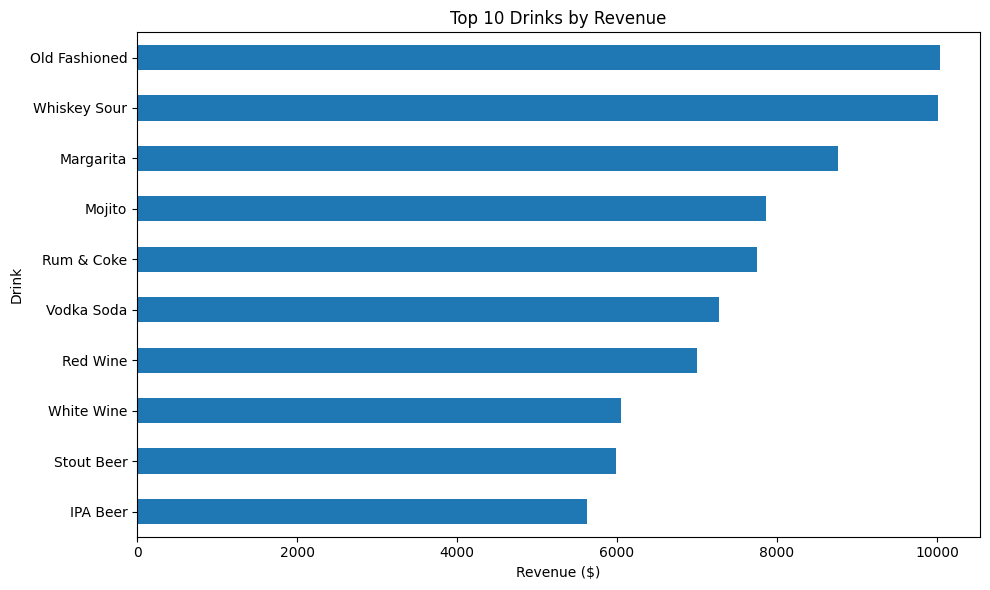

In [57]:
top_revenue.head(10).sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Drinks by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Drink")

plt.tight_layout()
plt.show()

In [64]:
hourly_sales = df.groupby("hour")["revenue"].sum().sort_index()


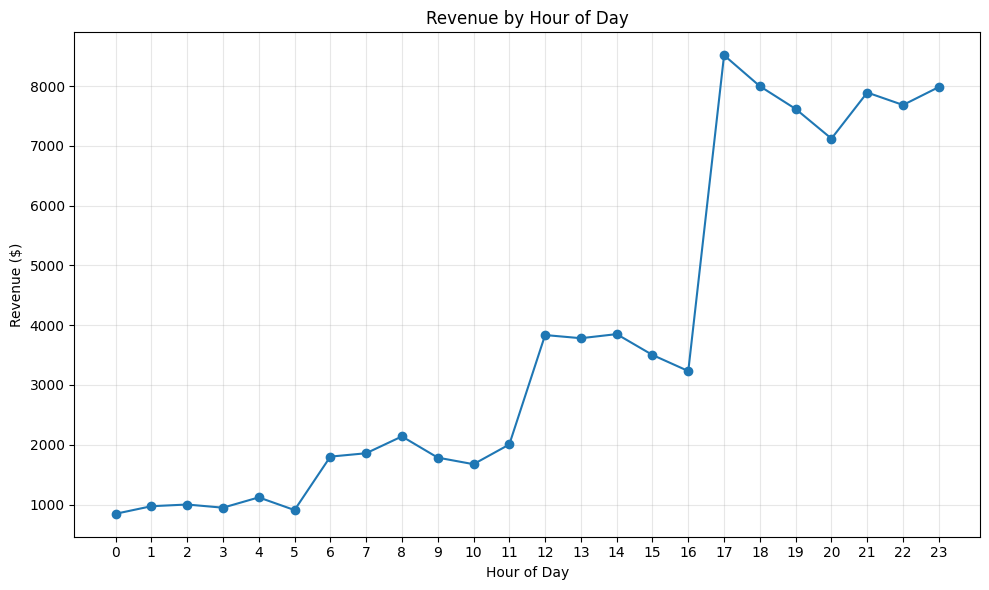

In [69]:
plt.figure(figsize=(10, 6))
plt.plot(hourly_sales.index, hourly_sales.values, marker="o")

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue ($)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

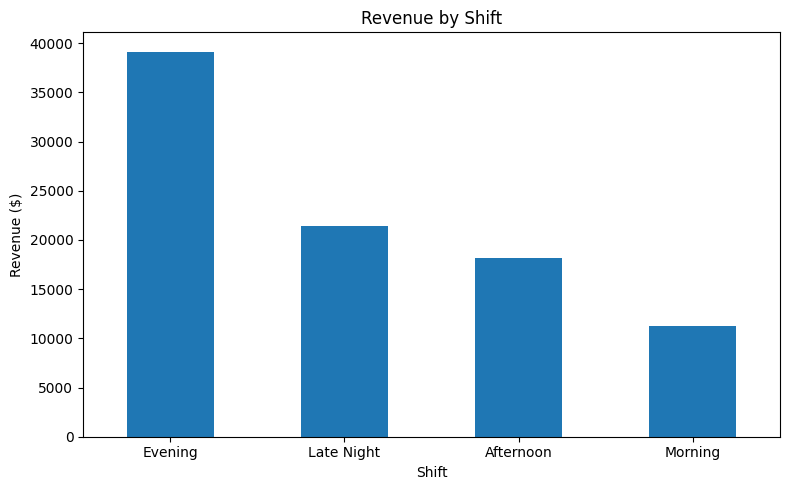

In [60]:
shift_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Revenue by Shift")
plt.xlabel("Shift")
plt.ylabel("Revenue ($)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

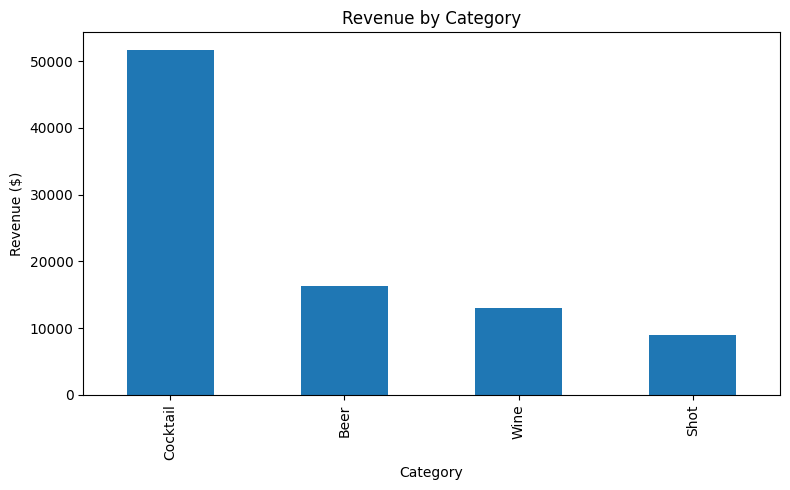

In [61]:
category_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")

plt.tight_layout()
plt.show()

In [79]:
plt.savefig("top_drinks.png")

<Figure size 640x480 with 0 Axes>

In [80]:
from google.colab import files
files.download("top_drinks.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
plt.savefig("category_sales.png")


<Figure size 640x480 with 0 Axes>

In [83]:
from google.colab import files
files.download("category_sales.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
plt.savefig("hourly_sales.png")

<Figure size 640x480 with 0 Axes>

In [85]:
from google.colab import files
files.download("hourly_sales.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [86]:
plt.savefig("shift_sales.png")

<Figure size 640x480 with 0 Axes>

In [87]:
from google.colab import files
files.download("shift_sales.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Key Insights:

- Premium cocktails such as Old Fashioneds and Whiskey Sours are the top revenue-generating items, indicating strong customer preference for higher-value drinks.
- Revenue is heavily concentrated in evening hours (5 PM–11 PM), aligning with typical after-work and nightlife demand patterns.
- The Evening shift accounts for the largest share of total revenue, making it the most critical operational window.
- Late-night sales remain strong, suggesting sustained demand beyond peak evening hours.
- Daytime (morning/afternoon) performance is significantly lower, indicating potential inefficiencies in staffing or opportunity for targeted promotions.

## Business Recommendations:

- Increase staffing levels during evening and late-night shifts to handle peak demand.
- Prioritize inventory stocking for top-performing cocktails (Old Fashioned, Whiskey Sour, Margarita).
- Introduce promotions or happy hour deals during afternoon hours to boost underperforming periods.
- Consider upselling premium cocktails, as customers show a clear preference for higher-priced drinks.
- Optimize scheduling to reduce labor costs during low-demand morning hours.

## Conclusion

This analysis demonstrates how transaction-level sales data can be used to inform operational decisions in a bar setting. By combining data cleaning, feature engineering, exploratory analysis, and visualization in Python, this project highlights how analytics can drive smarter staffing, inventory, and sales strategies.